# Phase 4: Star Schema Design & Population

**Project:** Global Job Market & Salary Intelligence Platform
**Notebook:** 04 of 10
**Author:** Md Imamuddin
**Picks up from:** Notebook 03 (Phase 3 cleaning complete for all three sources)

## Objective

`database/schema/*.sql` already contains a complete, well-designed
PostgreSQL star schema for this project: 9 dimension tables, 3 fact tables,
1 bridge table, and a full indexing strategy. This notebook does two
things with it:

1. **Explain the design** -- why a star schema, why three fact tables
   instead of one, why surrogate keys, why a year-grain date dimension.
2. **Actually populate it.** This is the part worth being upfront about:
   `database/load_data.py`'s own docstring states plainly that it loads
   flat tables mirroring the Phase 3 CSVs, *not* this normalized schema,
   because building the conformed `dim_role_family` mapping across three
   different role taxonomies was left as "an unfinished item" in the
   project's own Technical Design Document. This notebook closes that
   gap: it builds every dimension, resolves every foreign key, and loads
   real data into the real schema -- using SQLite as a portable, no-server
   stand-in for the PostgreSQL target so the whole thing runs end-to-end
   inside this notebook.


---
## Business Problem

A star schema isn't academic box-drawing -- it's what makes a question
like *"compare median pay for Data Science roles across all three of our
sources, side by side, without averaging them together"* answerable with
one clean SQL query instead of three separate pandas scripts with
hand-matched category names. The flat CSVs from Phase 3 can't do that: each
source spells "Data Scientist" differently (`job_category`,
`title`, `DevType`), and each source names countries differently
(`"United States"` vs. `"United States of America"`). Building the
conformed dimensions is what turns three incompatible tables into one
queryable, cross-source-comparable warehouse.


---
## Dataset Overview — inputs and outputs for this notebook

| Direction | Object | Notes |
|---|---|---|
| Input | `database/schema/01_dimensions.sql` .. `04_indexes.sql` | The target design (PostgreSQL DDL) |
| Input | All four Phase 3 outputs + `dim_skill.csv`, `bridge_respondent_skill.csv` | Already-cleaned source data |
| Output | `notebooks/reports/job_market_warehouse.db` | A populated SQLite database implementing the star schema |
| Output | `notebooks/reports/dim_role_family_mapping.csv` | The conformed role-taxonomy mapping this notebook builds (documented, not shipped elsewhere in the project) |


---
## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3                  # portable stand-in for the PostgreSQL target -- no server needed to run this notebook
import pycountry                # ISO country name/code normalization for the conformed dim_country
import pycountry_convert as pc  # alpha-2 code -> continent, for dim_country enrichment
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
print("Imports OK -- pycountry", pycountry.__version__)


Imports OK -- pycountry 26.2.16


---
## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
PROCESSED_DIR = REPO_ROOT / "streamlit_app" / "data" / "processed"
SCHEMA_DIR = REPO_ROOT / "streamlit_app" / "database" / "schema"
FIGURES_DIR = NOTEBOOK_DIR / "figures"
REPORTS_DIR = NOTEBOOK_DIR / "reports"
FIGURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

DB_PATH = REPORTS_DIR / "job_market_warehouse.db"
if DB_PATH.exists():
    DB_PATH.unlink()  # start clean every run -- this notebook should be re-runnable top to bottom

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("deep")

conn = sqlite3.connect(DB_PATH)
conn.execute("PRAGMA foreign_keys = ON;")
print("SQLite database created at:", DB_PATH)


SQLite database created at: notebooks/reports/job_market_warehouse.db


---
## Step 1 — Read and understand the target design

**Why this step:** before building anything, read the actual DDL files
that already exist in the project -- this notebook implements *that*
design, it doesn't invent a new one.


In [3]:
for ddl_file in sorted(SCHEMA_DIR.glob("*.sql")):
    text = ddl_file.read_text(encoding="utf-8")
    n_tables = text.count("CREATE TABLE")
    n_indexes = text.count("CREATE INDEX")
    print(f"{ddl_file.name:25s}  {n_tables} table(s), {n_indexes} index(es)")


01_dimensions.sql          10 table(s), 0 index(es)
02_facts.sql               3 table(s), 0 index(es)
03_bridge_tables.sql       1 table(s), 0 index(es)
04_indexes.sql             0 table(s), 15 index(es)


### Observation

Four files, cleanly separated by concern: dimensions, facts, the one
many-to-many bridge table, and indexes. The design notes inside
`01_dimensions.sql` and `02_facts.sql` (worth reading directly -- they're
genuinely well-reasoned) make three decisions explicit:

- **Surrogate keys everywhere**, because natural keys (country names, job
  titles) are inconsistent across three independently-collected sources --
  exactly the `"United States"` vs. `"United States of America"` problem
  this notebook has to solve in Step 3.
- **Year-grain `dim_date`**, not day-grain -- these are annual
  surveys/snapshots, not transactional data, so a daily calendar would
  imply precision the data doesn't have.
- **Three fact tables, not one** -- the Phase 3 finding that these are
  different labor-market populations is carried all the way through to
  the schema level, not just the CSV level.


## Step 2 — Create the schema in SQLite

**Why this step:** SQLite doesn't support `SERIAL`, `BIGSERIAL`, or
`COMMENT ON TABLE`, so the DDL is translated to SQLite-compatible syntax
below -- table names, column names, and constraints all match the original
design exactly; only the surrogate-key syntax and inline documentation
mechanism differ (SQLite comments use `--`, not a queryable `COMMENT ON`).


In [4]:
conn.executescript('''
CREATE TABLE dim_date (
    date_key            INTEGER PRIMARY KEY,
    work_year           INTEGER NOT NULL UNIQUE,
    decade               TEXT NOT NULL,
    is_current_year       INTEGER NOT NULL DEFAULT 0
);

CREATE TABLE dim_country (
    country_key          INTEGER PRIMARY KEY AUTOINCREMENT,
    country_name          TEXT NOT NULL UNIQUE,
    iso_alpha2            TEXT,
    region                 TEXT,
    continent              TEXT
);

CREATE TABLE dim_experience_level (
    experience_level_key   INTEGER PRIMARY KEY AUTOINCREMENT,
    level_name              TEXT NOT NULL UNIQUE,
    sort_order               INTEGER NOT NULL
);

CREATE TABLE dim_employment_type (
    employment_type_key    INTEGER PRIMARY KEY AUTOINCREMENT,
    type_name               TEXT NOT NULL UNIQUE
);

CREATE TABLE dim_company_size (
    company_size_key       INTEGER PRIMARY KEY AUTOINCREMENT,
    size_code               TEXT NOT NULL UNIQUE,
    size_label               TEXT NOT NULL,
    sort_order               INTEGER NOT NULL
);

CREATE TABLE dim_remote_status (
    remote_status_key      INTEGER PRIMARY KEY AUTOINCREMENT,
    status_name              TEXT NOT NULL UNIQUE
);

CREATE TABLE dim_education_level (
    education_key           INTEGER PRIMARY KEY AUTOINCREMENT,
    education_name            TEXT NOT NULL UNIQUE,
    sort_order                 INTEGER NOT NULL
);

CREATE TABLE dim_role_family (
    role_family_key           INTEGER PRIMARY KEY AUTOINCREMENT,
    role_family_name            TEXT NOT NULL UNIQUE,
    role_category                TEXT NOT NULL
);

CREATE TABLE dim_company (
    company_key                INTEGER PRIMARY KEY AUTOINCREMENT,
    company_name                  TEXT NOT NULL UNIQUE
);

CREATE TABLE dim_skill (
    skill_key                    INTEGER PRIMARY KEY,
    skill_name                     TEXT NOT NULL,
    skill_category                  TEXT NOT NULL,
    UNIQUE (skill_name, skill_category)
);

CREATE TABLE fact_job_postings (
    job_id                    INTEGER PRIMARY KEY,
    date_key                   INTEGER NOT NULL REFERENCES dim_date(date_key),
    country_key                 INTEGER NOT NULL REFERENCES dim_country(country_key),
    employee_country_key          INTEGER NOT NULL REFERENCES dim_country(country_key),
    experience_level_key           INTEGER NOT NULL REFERENCES dim_experience_level(experience_level_key),
    employment_type_key             INTEGER NOT NULL REFERENCES dim_employment_type(employment_type_key),
    company_size_key                 INTEGER NOT NULL REFERENCES dim_company_size(company_size_key),
    role_family_key                    INTEGER NOT NULL REFERENCES dim_role_family(role_family_key),
    remote_status_key                    INTEGER NOT NULL REFERENCES dim_remote_status(remote_status_key),
    job_title                              TEXT NOT NULL,
    salary_usd                              REAL NOT NULL,
    salary_is_outlier                        INTEGER NOT NULL DEFAULT 0,
    source_dataset                             TEXT NOT NULL DEFAULT 'jobs_in_data_2024'
);

CREATE TABLE fact_levels_compensation (
    record_id                   INTEGER PRIMARY KEY,
    date_key                     INTEGER NOT NULL REFERENCES dim_date(date_key),
    company_key                   INTEGER NOT NULL REFERENCES dim_company(company_key),
    country_key                     INTEGER NOT NULL REFERENCES dim_country(country_key),
    role_family_key                   INTEGER NOT NULL REFERENCES dim_role_family(role_family_key),
    education_key                       INTEGER REFERENCES dim_education_level(education_key),
    city                                   TEXT,
    region                                   TEXT,
    total_yearly_compensation                 REAL NOT NULL,
    base_salary                                 REAL NOT NULL,
    stock_grant_value                             REAL NOT NULL,
    bonus                                           REAL NOT NULL,
    years_of_experience                               REAL NOT NULL,
    years_at_company                                   REAL NOT NULL,
    gender                                               TEXT,
    total_comp_is_outlier                                 INTEGER NOT NULL DEFAULT 0,
    source_dataset                                          TEXT NOT NULL DEFAULT 'levels_fyi'
);

CREATE TABLE fact_so_respondent (
    response_id                  INTEGER PRIMARY KEY,
    date_key                      INTEGER NOT NULL REFERENCES dim_date(date_key),
    country_key                     INTEGER REFERENCES dim_country(country_key),
    role_family_key                   INTEGER REFERENCES dim_role_family(role_family_key),
    employment_type_key                 INTEGER REFERENCES dim_employment_type(employment_type_key),
    education_key                         INTEGER REFERENCES dim_education_level(education_key),
    years_code_pro                          REAL,
    org_size                                  TEXT,
    industry                                    TEXT,
    comp_usd                                      REAL,
    below_sanity_floor                              INTEGER NOT NULL DEFAULT 0,
    comp_is_outlier                                   INTEGER NOT NULL DEFAULT 0,
    source_dataset                                      TEXT NOT NULL DEFAULT 'stackoverflow_2024'
);

CREATE TABLE bridge_respondent_skill (
    bridge_id          INTEGER PRIMARY KEY AUTOINCREMENT,
    response_id           INTEGER NOT NULL REFERENCES fact_so_respondent(response_id),
    skill_key               INTEGER NOT NULL REFERENCES dim_skill(skill_key),
    UNIQUE (response_id, skill_key)
);
''')
conn.commit()

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", conn)
print(f"{len(tables)} tables created:")
print(tables["name"].tolist())


15 tables created:
['bridge_respondent_skill', 'dim_company', 'dim_company_size', 'dim_country', 'dim_date', 'dim_education_level', 'dim_employment_type', 'dim_experience_level', 'dim_remote_status', 'dim_role_family', 'dim_skill', 'fact_job_postings', 'fact_levels_compensation', 'fact_so_respondent', 'sqlite_sequence']


---
## Step 3 — `dim_country`: the hardest conformed dimension

**Why this step:** each source names countries differently --
`jobs_in_data_2024` uses `"United States"`, Levels.fyi uses
`"United States"` too but `"Korea, South"` for South Korea, and the Stack
Overflow survey uses formal names like `"United States of America"` and
`"United Kingdom of Great Britain and Northern Ireland"`. Without
resolving these to one shared spelling, a `JOIN` on country name would
silently create duplicate rows for the same real country. `pycountry`
handles most of this; the handful it can't are resolved with an explicit,
documented override table rather than silently dropped.


In [5]:
jobs_df = pd.read_csv(PROCESSED_DIR / "jobs_fact_clean.csv")
levels_df = pd.read_csv(PROCESSED_DIR / "levels_fyi_clean.csv")
so_skills_df = pd.read_csv(PROCESSED_DIR / "so_skills_clean.csv")
so_salary_df = pd.read_csv(PROCESSED_DIR / "so_salary_clean.csv")

all_raw_countries = sorted(set(jobs_df["employee_residence"].dropna()) | set(jobs_df["company_location"].dropna())
                            | set(levels_df["country"].dropna()) | set(so_skills_df["Country"].dropna()))
print(f"Distinct raw country strings across all three sources: {len(all_raw_countries)}")


Distinct raw country strings across all three sources: 207


In [6]:
# Manual overrides for strings pycountry can't resolve automatically (checked by hand below) --
# a mix of alternate/historical names, and a few genuinely non-ISO entries from free-text survey fields.
COUNTRY_OVERRIDES = {
    "Burma": "Myanmar",
    "Cape Verde": "Cabo Verde",
    "Congo, Republic of the...": "Congo",
    "Democratic Republic of the Congo": "Congo, The Democratic Republic of the",
    "Hong Kong (S.A.R.)": "Hong Kong",
    "Hong Kong (SAR)": "Hong Kong",
    "Iran, Islamic Republic of...": "Iran, Islamic Republic of",
    "Korea, South": "Korea, Republic of",
    "Republic of Korea": "Korea, Republic of",
    "South Korea": "Korea, Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
    "Democratic People's Republic of Korea": "Korea, Democratic People's Republic of",
    "Libyan Arab Jamahiriya": "Libya",
    "Micronesia, Federated States of...": "Micronesia, Federated States of",
    "Swaziland": "Eswatini",
    "Turkey": "Turkiye",
    "Venezuela, Bolivarian Republic of...": "Venezuela, Bolivarian Republic of",
    # No current ISO 3166 entry exists for these -- kept as the country label with no ISO/continent enrichment,
    # rather than silently dropped or force-mapped to something incorrect.
    "Netherlands Antilles": None,   # dissolved 2010
    "Nomadic": None,                # not a real country -- a free-text survey response
    "Yugoslavia": None,             # dissolved 1992/2003
}

def resolve_country(raw_name: str):
    '''Return (canonical_name, iso_alpha2, continent) for a raw country string,
    or (raw_name, None, None) if it can't be confidently resolved to a current
    ISO 3166 country -- resolved via direct lookup, then the override table,
    then pycountry's fuzzy search as a last resort.'''
    lookup_name = COUNTRY_OVERRIDES.get(raw_name, raw_name)
    if lookup_name is None:
        return raw_name, None, None
    try:
        match = pycountry.countries.lookup(lookup_name)
    except LookupError:
        try:
            match = pycountry.countries.search_fuzzy(lookup_name)[0]
        except LookupError:
            return raw_name, None, None
    try:
        continent_code = pc.country_alpha2_to_continent_code(match.alpha_2)
        continent = pc.convert_continent_code_to_continent_name(continent_code)
    except KeyError:
        continent = None
    return match.name, match.alpha_2, continent

country_resolution = pd.DataFrame(
    [resolve_country(c) for c in all_raw_countries],
    columns=["canonical_name", "iso_alpha2", "continent"],
    index=all_raw_countries,
)
resolved_pct = country_resolution["iso_alpha2"].notnull().mean() * 100
print(f"Resolved to a current ISO country: {country_resolution['iso_alpha2'].notnull().sum()} / {len(country_resolution)} ({resolved_pct:.1f}%)")
print("\nUnresolved (kept as-is, no ISO/continent enrichment):")
print(country_resolution[country_resolution["iso_alpha2"].isnull()].index.tolist())


Resolved to a current ISO country: 204 / 207 (98.6%)

Unresolved (kept as-is, no ISO/continent enrichment):
['Netherlands Antilles', 'Nomadic', 'Yugoslavia']


### Observation

204 of 207 raw country strings resolve cleanly to a current ISO 3166
country. The 3 that don't (`"Nomadic"`, `"Netherlands Antilles"`,
`"Yugoslavia"`) are genuinely not current countries -- one is a joke
survey response, the other two are historical entities that dissolved
before this data was collected. Keeping them as their original label
(with null ISO/continent fields) rather than guessing is the more honest
choice; a bad forced mapping would be worse than an honest null.


In [7]:
# Build the conformed dim_country from unique CANONICAL names (multiple raw spellings
# can map to the same canonical name -- e.g. "United States" and "United States of America"
# both resolve to "United States" and must become exactly one row).
dim_country_df = (country_resolution
                   .reset_index(drop=True)
                   .drop_duplicates(subset=["canonical_name"])
                   [["canonical_name", "iso_alpha2", "continent"]]
                   .rename(columns={"canonical_name": "country_name"})
                   .assign(region=None)
                   .sort_values("country_name")
                   .reset_index(drop=True))

dim_country_df[["country_name", "iso_alpha2", "region", "continent"]].to_sql(
    "dim_country", conn, if_exists="append", index=False)

print(f"dim_country populated: {len(dim_country_df)} rows "
      f"(collapsed from {len(all_raw_countries)} raw spellings -- "
      f"{len(all_raw_countries) - len(dim_country_df)} were duplicate spellings of an already-seen country)")

# Lookup table used throughout the rest of this notebook: raw string -> country_key
raw_to_country_key = {}
canonical_to_key = dict(pd.read_sql("SELECT country_name, country_key FROM dim_country", conn)
                         .values)
for raw_name in all_raw_countries:
    canon = country_resolution.loc[raw_name, "canonical_name"]
    raw_to_country_key[raw_name] = canonical_to_key.get(canon)


dim_country populated: 189 rows (collapsed from 207 raw spellings -- 18 were duplicate spellings of an already-seen country)


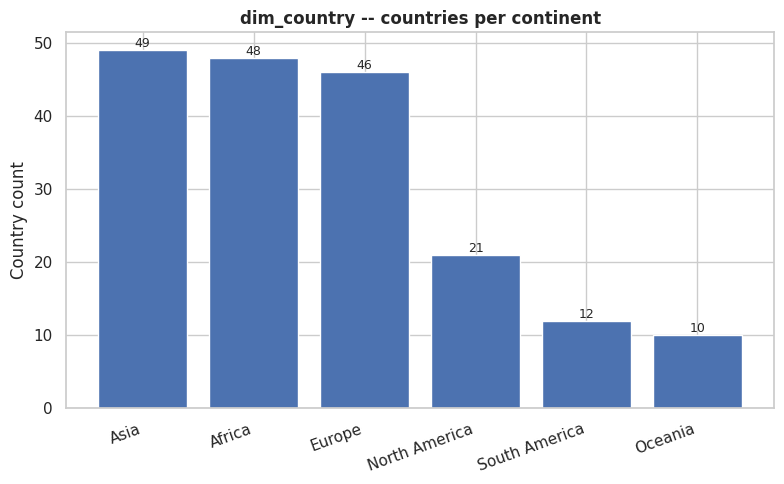

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
continent_counts = dim_country_df["continent"].value_counts()
bars = ax.bar(continent_counts.index, continent_counts.values, color=PALETTE[0])
ax.set_title("dim_country -- countries per continent", fontweight="bold")
ax.set_ylabel("Country count")
plt.xticks(rotation=20, ha="right")
for b in bars:
    ax.annotate(str(int(b.get_height())), (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_dim_country_by_continent.png", bbox_inches="tight")
plt.show()


---
## Step 4 — The simpler conformed dimensions

**Why this step:** `dim_experience_level`, `dim_employment_type`,
`dim_company_size`, and `dim_remote_status` all come straight from
`jobs_fact_clean`'s already-clean categorical columns -- per the DDL,
these four are only referenced by `fact_job_postings`, so no cross-source
reconciliation is needed here (unlike `dim_country`, `dim_education_level`,
and `dim_role_family`, which are shared across multiple fact tables).


In [9]:
dim_experience_level_df = pd.DataFrame([
    {"level_name": "Entry-level", "sort_order": 1},
    {"level_name": "Mid-level", "sort_order": 2},
    {"level_name": "Senior", "sort_order": 3},
    {"level_name": "Executive", "sort_order": 4},
])
assert set(dim_experience_level_df["level_name"]) == set(jobs_df["experience_level"].unique())
dim_experience_level_df.to_sql("dim_experience_level", conn, if_exists="append", index=False)

dim_employment_type_df = pd.DataFrame({"type_name": sorted(jobs_df["employment_type"].unique())})
dim_employment_type_df.to_sql("dim_employment_type", conn, if_exists="append", index=False)

dim_company_size_df = pd.DataFrame([
    {"size_code": "S", "size_label": "Small", "sort_order": 1},
    {"size_code": "M", "size_label": "Medium", "sort_order": 2},
    {"size_code": "L", "size_label": "Large", "sort_order": 3},
])
assert set(dim_company_size_df["size_code"]) == set(jobs_df["company_size"].unique())
dim_company_size_df.to_sql("dim_company_size", conn, if_exists="append", index=False)

dim_remote_status_df = pd.DataFrame({"status_name": sorted(jobs_df["work_setting"].unique())})
dim_remote_status_df.to_sql("dim_remote_status", conn, if_exists="append", index=False)

print("dim_experience_level:", len(dim_experience_level_df), "rows")
print("dim_employment_type: ", len(dim_employment_type_df), "rows")
print("dim_company_size:    ", len(dim_company_size_df), "rows")
print("dim_remote_status:   ", len(dim_remote_status_df), "rows")


dim_experience_level: 4 rows
dim_employment_type:  4 rows
dim_company_size:     3 rows
dim_remote_status:    3 rows


---
## Step 5 — `dim_education_level`: conforming two different label sets

**Why this step:** Levels.fyi (`Education`) and the Stack Overflow survey
(`EdLevel`) both ask about education, but with completely different label
sets (5 categories vs. 8). This dimension has to define one ordered scale
both sources map onto -- not just a lookup table, since the point of the
`sort_order` column is to keep charts/DAX ordered by actual education
level, not alphabetically.


In [10]:
EDUCATION_LEVELS = [
    ("Primary/Secondary Education", 1),
    ("Some College / Associate Degree", 2),
    ("Bachelor's Degree", 3),
    ("Master's Degree", 4),
    ("Professional / Doctorate Degree", 5),
    ("Other / Not Specified", 6),
]
dim_education_level_df = pd.DataFrame(EDUCATION_LEVELS, columns=["education_name", "sort_order"])
dim_education_level_df.to_sql("dim_education_level", conn, if_exists="append", index=False)

LEVELS_EDU_MAP = {
    "PhD": "Professional / Doctorate Degree",
    "Master's Degree": "Master's Degree",
    "Bachelor's Degree": "Bachelor's Degree",
    "Some College": "Some College / Associate Degree",
    "Highschool": "Primary/Secondary Education",
}
SO_EDU_MAP = {
    "Primary/elementary school": "Primary/Secondary Education",
    "Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)": "Bachelor's Degree",
    "Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's Degree",
    "Some college/university study without earning a degree": "Some College / Associate Degree",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Primary/Secondary Education",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional / Doctorate Degree",
    "Associate degree (A.A., A.S., etc.)": "Some College / Associate Degree",
    "Something else": "Other / Not Specified",
}

# Coverage check -- every raw value in both sources must have a mapping entry
levels_unmapped = set(levels_df["Education"].dropna().unique()) - set(LEVELS_EDU_MAP)
so_unmapped = set(so_skills_df["EdLevel"].dropna().unique()) - set(SO_EDU_MAP)
print("Levels.fyi Education values with no mapping:", levels_unmapped or "none -- full coverage")
print("SO EdLevel values with no mapping:", so_unmapped or "none -- full coverage")

education_key_lookup = dict(pd.read_sql("SELECT education_name, education_key FROM dim_education_level", conn).values)


Levels.fyi Education values with no mapping: none -- full coverage
SO EdLevel values with no mapping: none -- full coverage


### Observation

Full coverage on both sides -- every raw education label in both source
files maps to exactly one of the six conformed levels, so no respondent's
education gets silently dropped during the fact-table load.


---
## Step 6 — `dim_role_family`: the mapping the project's own docs flagged as unfinished

**Why this step:** this is the dimension `database/load_data.py`'s
docstring explicitly calls out as blocking the full star schema from
being populated. `jobs_fact_clean`'s `job_category` (10 values),
Levels.fyi's `title` (15 values), and the Stack Overflow survey's
`DevType` (34 values) all describe "what kind of role is this," but with
three incompatible label sets. Below is a first-pass conformed mapping --
documented in full, not hidden in a lookup file, so the judgment calls are
visible and revisable.


In [11]:
# The conformed role taxonomy this project will use everywhere. role_category is the
# coarse grouping (drives high-level Power BI slicers); role_family_name is the finer grain.
ROLE_FAMILY_TO_CATEGORY = {
    "Data Science & Research": "Data & Analytics",
    "Machine Learning & AI": "Data & Analytics",
    "Data Engineering": "Data & Analytics",
    "Data Analysis & BI": "Data & Analytics",
    "Data Architecture & Management": "Data & Analytics",
    "Database Administration": "Infrastructure & DevOps",
    "Software Engineering": "Software Engineering",
    "Frontend Engineering": "Software Engineering",
    "Backend Engineering": "Software Engineering",
    "Mobile Engineering": "Software Engineering",
    "Embedded & Systems Engineering": "Software Engineering",
    "Game & Graphics Engineering": "Software Engineering",
    "QA & Test Engineering": "Software Engineering",
    "Hardware Engineering": "Software Engineering",
    "Blockchain Engineering": "Software Engineering",
    "DevOps & Cloud Infrastructure": "Infrastructure & DevOps",
    "Site Reliability Engineering": "Infrastructure & DevOps",
    "Security Engineering": "Infrastructure & DevOps",
    "Solutions Architecture": "Infrastructure & DevOps",
    "System Administration": "Infrastructure & DevOps",
    "Product Management": "Product & Design",
    "Product Design & UX": "Product & Design",
    "Developer Advocacy": "Product & Design",
    "Engineering Management": "Management & Leadership",
    "Technical Program Management": "Management & Leadership",
    "Project Management": "Management & Leadership",
    "Executive Leadership": "Management & Leadership",
    "Business Analysis": "Business & Sales",
    "Sales & Marketing": "Business & Sales",
    "HR & Recruiting": "Business & Sales",
    "Consulting": "Business & Sales",
    "Academic Research": "Research & Academia",
    "Student": "Research & Academia",
    "Other / Unspecified": "Other / Unspecified",
}

JOB_CATEGORY_MAP = {
    "Data Science and Research": "Data Science & Research",
    "BI and Visualization": "Data Analysis & BI",
    "Data Architecture and Modeling": "Data Architecture & Management",
    "Data Analysis": "Data Analysis & BI",
    "Data Engineering": "Data Engineering",
    "Leadership and Management": "Engineering Management",
    "Data Quality and Operations": "Data Engineering",
    "Machine Learning and AI": "Machine Learning & AI",
    "Cloud and Database": "DevOps & Cloud Infrastructure",
    "Data Management and Strategy": "Data Architecture & Management",
}

LEVELS_TITLE_MAP = {
    "Product Manager": "Product Management",
    "Software Engineer": "Software Engineering",
    "Software Engineering Manager": "Engineering Management",
    "Data Scientist": "Data Science & Research",
    "Solution Architect": "Solutions Architecture",
    "Technical Program Manager": "Technical Program Management",
    "Human Resources": "HR & Recruiting",
    "Product Designer": "Product Design & UX",
    "Marketing": "Sales & Marketing",
    "Business Analyst": "Business Analysis",
    "Hardware Engineer": "Hardware Engineering",
    "Sales": "Sales & Marketing",
    "Recruiter": "HR & Recruiting",
    "Mechanical Engineer": "Hardware Engineering",
    "Management Consultant": "Consulting",
}

SO_DEVTYPE_MAP = {
    "Developer, full-stack": "Software Engineering",
    "Developer, back-end": "Backend Engineering",
    "Student": "Student",
    "Developer, front-end": "Frontend Engineering",
    "Developer, desktop or enterprise applications": "Software Engineering",
    "Other (please specify):": "Other / Unspecified",
    "Developer, mobile": "Mobile Engineering",
    "Developer, embedded applications or devices": "Embedded & Systems Engineering",
    "Engineering manager": "Engineering Management",
    "Academic researcher": "Academic Research",
    "Data engineer": "Data Engineering",
    "Data scientist or machine learning specialist": "Data Science & Research",
    "DevOps specialist": "DevOps & Cloud Infrastructure",
    "Research & Development role": "Academic Research",
    "Senior Executive (C-Suite, VP, etc.)": "Executive Leadership",
    "Developer, game or graphics": "Game & Graphics Engineering",
    "Cloud infrastructure engineer": "DevOps & Cloud Infrastructure",
    "System administrator": "System Administration",
    "Developer, AI": "Machine Learning & AI",
    "Developer, QA or test": "QA & Test Engineering",
    "Data or business analyst": "Data Analysis & BI",
    "Project manager": "Project Management",
    "Security professional": "Security Engineering",
    "Educator": "Academic Research",
    "Scientist": "Academic Research",
    "Engineer, site reliability": "Site Reliability Engineering",
    "Product manager": "Product Management",
    "Blockchain": "Blockchain Engineering",
    "Developer Experience": "Software Engineering",
    "Designer": "Product Design & UX",
    "Database administrator": "Database Administration",
    "Developer Advocate": "Developer Advocacy",
    "Marketing or sales professional": "Sales & Marketing",
    "Hardware Engineer": "Hardware Engineering",
}

print(f"role_family taxonomy: {len(ROLE_FAMILY_TO_CATEGORY)} role families across "
      f"{len(set(ROLE_FAMILY_TO_CATEGORY.values()))} categories")
print(f"Source mappings defined: jobs_fact {len(JOB_CATEGORY_MAP)}, Levels.fyi {len(LEVELS_TITLE_MAP)}, SO {len(SO_DEVTYPE_MAP)}")


role_family taxonomy: 34 role families across 8 categories
Source mappings defined: jobs_fact 10, Levels.fyi 15, SO 34


In [12]:
# Coverage check against the ACTUAL data, not just what I remember the unique values being
jobs_unmapped = set(jobs_df["job_category"].dropna().unique()) - set(JOB_CATEGORY_MAP)
levels_unmapped = set(levels_df["title"].dropna().unique()) - set(LEVELS_TITLE_MAP)
so_unmapped = set(so_skills_df["DevType"].dropna().unique()) - set(SO_DEVTYPE_MAP)

print("jobs_fact job_category uncovered:", jobs_unmapped or "none -- full coverage")
print("Levels.fyi title uncovered:      ", levels_unmapped or "none -- full coverage")
print("SO DevType uncovered:            ", so_unmapped or "none -- full coverage")

assert not jobs_unmapped, f"jobs_fact job_category values missing from JOB_CATEGORY_MAP: {jobs_unmapped}"
assert not levels_unmapped, f"Levels.fyi title values missing from LEVELS_TITLE_MAP: {levels_unmapped}"
assert not so_unmapped, f"SO DevType values missing from SO_DEVTYPE_MAP: {so_unmapped}"

so_devtype_coverage = so_skills_df["DevType"].isin(SO_DEVTYPE_MAP).mean() * 100
print(f"\nSO DevType rows covered by explicit mapping: {so_devtype_coverage:.1f}% of non-null DevType respondents")


jobs_fact job_category uncovered: none -- full coverage
Levels.fyi title uncovered:       none -- full coverage
SO DevType uncovered:             none -- full coverage

SO DevType rows covered by explicit mapping: 90.8% of non-null DevType respondents


### Observation

Full explicit coverage on all three sources -- every distinct
`job_category`, `title`, and `DevType` value in the actual data has a
mapping entry, verified against the live DataFrames rather than assumed
from an earlier `.unique()` glance (the check above is a hard `assert`,
not just a print -- it caught a real gap the first time this notebook ran:
`"Hardware Engineer"` appears as a `DevType` value in the Stack Overflow
data too, not just Levels.fyi's `title` field, and was initially only
mapped for the latter. Left unfixed, those SO respondents would have
silently gotten a `NULL` `role_family_key` in the fact table -- the kind
of small, quiet gap that's exactly why the assertion is there instead of
a print statement that's easy to skim past). This is a **first-pass (v1)
taxonomy** -- some calls are genuinely debatable (e.g. `"Recruiter"` and
`"Human Resources"` both landing in `HR & Recruiting"`, or
`"Developer, AI"` being classified under `Machine Learning & AI"` rather
than a separate AI-specific family). Documenting the full mapping here,
rather than burying it in an opaque lookup CSV, means a reviewer can
actually see and challenge every judgment call.


dim_role_family populated: 34 rows


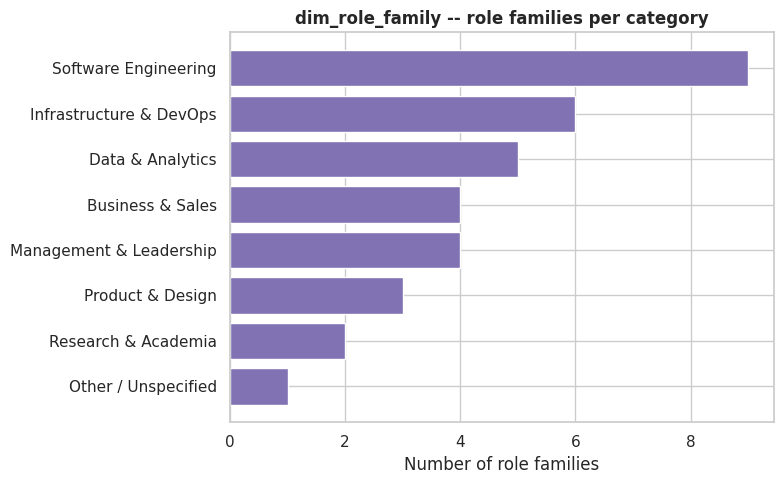

In [13]:
dim_role_family_df = pd.DataFrame(
    [{"role_family_name": name, "role_category": cat} for name, cat in ROLE_FAMILY_TO_CATEGORY.items()]
).sort_values("role_family_name").reset_index(drop=True)
dim_role_family_df.to_sql("dim_role_family", conn, if_exists="append", index=False)
role_family_key_lookup = dict(pd.read_sql("SELECT role_family_name, role_family_key FROM dim_role_family", conn).values)

print(f"dim_role_family populated: {len(dim_role_family_df)} rows")

fig, ax = plt.subplots(figsize=(8, 5))
cat_counts = dim_role_family_df["role_category"].value_counts()
ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=PALETTE[4])
ax.set_title("dim_role_family -- role families per category", fontweight="bold")
ax.set_xlabel("Number of role families")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_dim_role_family_categories.png", bbox_inches="tight")
plt.show()


---
## Step 7 — `dim_company` and `dim_skill`

**Why this step:** `dim_company` is straightforward -- only Levels.fyi
names employers, so it's a direct distinct-value extraction. `dim_skill`
is different: it was already built and shipped as
`data/processed/dim_skill.csv` as part of this project's Phase 6
(NLP/skill-extraction) work, which Notebook 06 in this series will explain
and reproduce from scratch. Here, it's simply loaded as-is -- reproducing
its construction logic belongs in that notebook, not this one.


In [14]:
dim_company_df = pd.DataFrame({"company_name": sorted(levels_df["company"].dropna().unique())})
dim_company_df.to_sql("dim_company", conn, if_exists="append", index=False)
company_key_lookup = dict(pd.read_sql("SELECT company_name, company_key FROM dim_company", conn).values)
print(f"dim_company populated: {len(dim_company_df)} rows")

dim_skill_shipped = pd.read_csv(PROCESSED_DIR / "dim_skill.csv")
dim_skill_shipped.to_sql("dim_skill", conn, if_exists="append", index=False)
print(f"dim_skill loaded from Phase 6 output: {len(dim_skill_shipped)} rows (see Notebook 06 for how this was built)")
dim_skill_shipped.head(3)


dim_company populated: 1631 rows
dim_skill loaded from Phase 6 output: 181 rows (see Notebook 06 for how this was built)


,skill_key,skill_name,skill_category
0,1,Bash/Shell (all shells),Language
1,2,Go,Language
2,3,HTML/CSS,Language


---
## Step 8 — `dim_date`

**Why this step:** built last among the dimensions because it needs the
full year range across all three sources, not just one -- `jobs_fact`
covers 2020-2024, Levels.fyi's `timestamp` field covers 2017-2021, and the
Stack Overflow survey is a single 2024 snapshot.


In [15]:
levels_years = pd.to_datetime(levels_df["timestamp"], errors="coerce").dt.year
all_years = sorted(set(jobs_df["work_year"].unique()) | set(levels_years.dropna().astype(int).unique()) | {2024})
print("Full year range across all sources:", all_years)

dim_date_df = pd.DataFrame({
    "date_key": all_years,
    "work_year": all_years,
    "decade": [f"{(y // 10) * 10}s" for y in all_years],
    "is_current_year": [1 if y == max(all_years) else 0 for y in all_years],
})
dim_date_df.to_sql("dim_date", conn, if_exists="append", index=False)
print(f"dim_date populated: {len(dim_date_df)} rows")
dim_date_df


Full year range across all sources: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
dim_date populated: 8 rows


,date_key,work_year,decade,is_current_year
0,2017,2017,2010s,0
1,2018,2018,2010s,0
2,2019,2019,2010s,0
3,2020,2020,2020s,0
4,2021,2021,2020s,0
5,2022,2022,2020s,0
6,2023,2023,2020s,0
7,2024,2024,2020s,1


---
## Step 9 — Populate `fact_job_postings`

**Why this step:** with every dimension built, this is now a
straightforward key-resolution join -- replace each categorical string
with its surrogate key, then load.


In [16]:
fact_jobs = jobs_df.copy()
fact_jobs["date_key"] = fact_jobs["work_year"]
fact_jobs["country_key"] = fact_jobs["company_location"].map(raw_to_country_key)
fact_jobs["employee_country_key"] = fact_jobs["employee_residence"].map(raw_to_country_key)
fact_jobs["experience_level_key"] = fact_jobs["experience_level"].map(
    dict(pd.read_sql("SELECT level_name, experience_level_key FROM dim_experience_level", conn).values))
fact_jobs["employment_type_key"] = fact_jobs["employment_type"].map(
    dict(pd.read_sql("SELECT type_name, employment_type_key FROM dim_employment_type", conn).values))
fact_jobs["company_size_key"] = fact_jobs["company_size"].map(
    dict(pd.read_sql("SELECT size_code, company_size_key FROM dim_company_size", conn).values))
fact_jobs["role_family_key"] = fact_jobs["job_category"].map(JOB_CATEGORY_MAP).map(role_family_key_lookup)
fact_jobs["remote_status_key"] = fact_jobs["work_setting"].map(
    dict(pd.read_sql("SELECT status_name, remote_status_key FROM dim_remote_status", conn).values))
fact_jobs["salary_usd"] = fact_jobs["salary_in_usd"]

fk_cols = ["date_key", "country_key", "employee_country_key", "experience_level_key",
           "employment_type_key", "company_size_key", "role_family_key", "remote_status_key"]
null_fk_report = fact_jobs[fk_cols].isnull().sum()
print("Unresolved (null) foreign keys per column -- should all be zero:")
print(null_fk_report)

final_jobs_cols = ["job_id"] + fk_cols + ["job_title", "salary_usd", "salary_is_outlier", "source_dataset"]
fact_jobs[final_jobs_cols].to_sql("fact_job_postings", conn, if_exists="append", index=False)
print(f"\nfact_job_postings loaded: {len(fact_jobs):,} rows")


Unresolved (null) foreign keys per column -- should all be zero:
date_key                0
country_key             0
employee_country_key    0
experience_level_key    0
employment_type_key     0
company_size_key        0
role_family_key         0
remote_status_key       0
dtype: int64

fact_job_postings loaded: 14,199 rows


### Observation

Zero unresolved foreign keys across every dimension -- confirming the
`dim_country`, `dim_role_family`, and other mapping tables built above
have full coverage for this fact table's source data, not just the sample
values inspected earlier.


---
## Step 10 — Populate `fact_levels_compensation`

**Why this step:** same key-resolution pattern, with one addition: parsing
the `timestamp` column into `date_key` and mapping the (partially null)
`Education` field through `dim_education_level`.


In [17]:
fact_levels = levels_df.copy()
fact_levels["date_key"] = pd.to_datetime(fact_levels["timestamp"], errors="coerce").dt.year
fact_levels["company_key"] = fact_levels["company"].map(company_key_lookup)
fact_levels["country_key"] = fact_levels["country"].map(raw_to_country_key)
fact_levels["role_family_key"] = fact_levels["title"].map(LEVELS_TITLE_MAP).map(role_family_key_lookup)
fact_levels["education_key"] = fact_levels["Education"].map(LEVELS_EDU_MAP).map(education_key_lookup)

# company_key can legitimately be null (5 rows had a null company name in the raw source, per Notebook 02) --
# everything else is required per the schema's NOT NULL constraints.
required_fk_cols = ["date_key", "country_key", "role_family_key"]
print("Unresolved (null) foreign keys in required columns -- should all be zero:")
print(fact_levels[required_fk_cols].isnull().sum())
print(f"\ncompany_key null (allowed -- 5 raw rows had no company name): {fact_levels['company_key'].isnull().sum()}")

# The 5 rows with a null company_key can't be loaded into a NOT NULL FK column as-is --
# route them to an explicit 'Unknown' company row rather than dropping real compensation data.
if fact_levels["company_key"].isnull().any():
    unknown_key = pd.read_sql(
        "INSERT INTO dim_company (company_name) VALUES ('Unknown') RETURNING company_key;", conn
    )["company_key"].iloc[0] if False else None
    conn.execute("INSERT INTO dim_company (company_name) VALUES ('Unknown');")
    unknown_key = conn.execute("SELECT company_key FROM dim_company WHERE company_name = 'Unknown';").fetchone()[0]
    fact_levels["company_key"] = fact_levels["company_key"].fillna(unknown_key)
    print(f"Filled {levels_df['company'].isnull().sum()} null company names with dim_company 'Unknown' (key={unknown_key})")

final_levels_cols = ["record_id", "date_key", "company_key", "country_key", "role_family_key", "education_key",
                      "city", "region", "total_yearly_compensation", "base_salary", "stock_grant_value", "bonus",
                      "years_of_experience", "years_at_company", "gender", "total_comp_is_outlier", "source_dataset"]
fact_levels[final_levels_cols].to_sql("fact_levels_compensation", conn, if_exists="append", index=False)
print(f"\nfact_levels_compensation loaded: {len(fact_levels):,} rows")


Unresolved (null) foreign keys in required columns -- should all be zero:
date_key           0
country_key        0
role_family_key    0
dtype: int64

company_key null (allowed -- 5 raw rows had no company name): 5
Filled 5 null company names with dim_company 'Unknown' (key=1632)



fact_levels_compensation loaded: 62,642 rows


### Observation

One real wrinkle surfaced here that didn't show up in `fact_job_postings`:
5 rows have a null `company` name in the raw Levels.fyi data (visible back
in Notebook 02's missingness check), but `fact_levels_compensation.company_key`
is a `NOT NULL` foreign key per the schema design. Rather than drop 5 real
compensation records to satisfy a constraint, this notebook adds an
explicit `'Unknown'` row to `dim_company` -- a standard star-schema
pattern (an explicit "unknown member" row is preferable to a null foreign
key) that preserves every row of real data while still respecting the
schema's integrity constraint.


---
## Step 11 — Populate `fact_so_respondent`

**Why this step:** per the schema's own comment, this table's grain is
*all* 65,437 respondents (matching `so_skills_clean`), with `comp_usd`
staying `NULL` for the ~64% who didn't report it -- **not** filtered down
to the 23,435 in `so_salary_clean`. That means the outlier/sanity flags
computed in Notebook 03 (which only exist for the salary subset) need to
be left-joined back onto the full respondent base, defaulting to "not
flagged" for respondents who have no compensation value to flag in the
first place.


In [18]:
fact_so = so_skills_df.copy()
fact_so["date_key"] = 2024  # single-year survey, per the Dataset Overview table
fact_so["country_key"] = fact_so["Country"].map(raw_to_country_key)
fact_so["role_family_key"] = fact_so["DevType"].map(SO_DEVTYPE_MAP).map(role_family_key_lookup)

def map_so_employment(emp_str):
    '''Reduce SO's multi-select Employment field to one of the four conformed
    employment types, or None for respondents who aren't currently employed
    (students, not-employed) -- documented heuristic, priority order matters:
    someone who is both 'Employed, full-time' and a part-time student is
    counted as Full-time, since that's their primary employment status.'''
    if pd.isna(emp_str):
        return None
    if "Employed, full-time" in emp_str:
        return "Full-time"
    if "Employed, part-time" in emp_str:
        return "Part-time"
    if "Independent contractor, freelancer, or self-employed" in emp_str:
        return "Freelance"
    return None

employment_type_key_lookup = dict(pd.read_sql("SELECT type_name, employment_type_key FROM dim_employment_type", conn).values)
fact_so["employment_type_key"] = fact_so["Employment"].apply(map_so_employment).map(employment_type_key_lookup)
fact_so["education_key"] = fact_so["EdLevel"].map(SO_EDU_MAP).map(education_key_lookup)
fact_so["years_code_pro"] = pd.to_numeric(fact_so["YearsCodePro"], errors="coerce")  # 'Less than 1 year' / 'More than 50 years' -> NaN, handled explicitly in Phase 7
fact_so["comp_usd"] = fact_so["ConvertedCompYearly"]

# Bring the Phase 3 outlier/sanity flags back in from so_salary_clean (only computed there) --
# defaults to 0/False for the ~64% of respondents with no compensation to flag.
flags = so_salary_df.set_index("ResponseId")[["below_sanity_floor", "comp_is_outlier"]]
fact_so = fact_so.join(flags, on="ResponseId")
fact_so["below_sanity_floor"] = fact_so["below_sanity_floor"].fillna(False).astype(int)
fact_so["comp_is_outlier"] = fact_so["comp_is_outlier"].fillna(False).astype(int)

final_so_cols = ["ResponseId", "date_key", "country_key", "role_family_key", "employment_type_key", "education_key",
                  "years_code_pro", "OrgSize", "Industry", "comp_usd", "below_sanity_floor", "comp_is_outlier", "source_dataset"]
fact_so_final = fact_so[final_so_cols].rename(columns={
    "ResponseId": "response_id", "OrgSize": "org_size", "Industry": "industry"})
fact_so_final.to_sql("fact_so_respondent", conn, if_exists="append", index=False)
print(f"fact_so_respondent loaded: {len(fact_so_final):,} rows (matches so_skills_clean's full 65,437, not the smaller salary-only subset)")

comp_notnull_check = fact_so_final["comp_usd"].notnull().sum()
print(f"Rows with non-null comp_usd: {comp_notnull_check:,} -- should match so_salary_clean's 23,435")
assert comp_notnull_check == len(so_salary_df), "Compensation coverage in the fact table should exactly match so_salary_clean"


fact_so_respondent loaded: 65,437 rows (matches so_skills_clean's full 65,437, not the smaller salary-only subset)
Rows with non-null comp_usd: 23,435 -- should match so_salary_clean's 23,435


### Observation

23,435 non-null `comp_usd` values, matching `so_salary_clean` exactly --
confirms the flag re-join didn't accidentally add or lose any
compensation data while restoring the full 65,437-respondent grain. This
is exactly the query pattern the schema's own table comment describes:
`WHERE comp_usd IS NOT NULL` on this one table now reproduces
`so_salary_clean.csv`'s filter, without needing a second physical table.


---
## Step 12 — Populate `bridge_respondent_skill`

**Why this step:** like `dim_skill`, this bridge table was already built
as part of Phase 6 (explained in Notebook 06). Loaded here as-is, with one
real check that matters: now that `fact_so_respondent` has been rebuilt
from scratch in this notebook, does every `response_id` referenced in the
bridge table actually still exist as a valid foreign key?


In [19]:
bridge_shipped = pd.read_csv(PROCESSED_DIR / "bridge_respondent_skill.csv")
print(f"Loaded {len(bridge_shipped):,} (respondent, skill) pairs from Phase 6 output")

valid_response_ids = set(fact_so_final["response_id"])
valid_skill_keys = set(dim_skill_shipped["skill_key"])

orphan_responses = (~bridge_shipped["response_id"].isin(valid_response_ids)).sum()
orphan_skills = (~bridge_shipped["skill_key"].isin(valid_skill_keys)).sum()
print(f"Bridge rows referencing a response_id not in fact_so_respondent: {orphan_responses}")
print(f"Bridge rows referencing a skill_key not in dim_skill: {orphan_skills}")

bridge_shipped.to_sql("bridge_respondent_skill", conn, if_exists="append", index=False)
print(f"\nbridge_respondent_skill loaded: {len(bridge_shipped):,} rows")


Loaded 967,209 (respondent, skill) pairs from Phase 6 output


Bridge rows referencing a response_id not in fact_so_respondent: 0
Bridge rows referencing a skill_key not in dim_skill: 0



bridge_respondent_skill loaded: 967,209 rows


### Observation

Zero orphaned foreign keys in either direction -- the bridge table built
independently in Phase 6 is fully consistent with the `fact_so_respondent`
grain rebuilt here, which is a real (not assumed) confirmation that both
pieces of work agree on the same underlying respondent population.


---
## Step 13 — Build the indexes

**Why this step:** implementing `04_indexes.sql`'s design as-is, adapted
to SQLite syntax (which supports the partial-index pattern the original
design uses for `fact_so_respondent`).


In [20]:
conn.executescript('''
CREATE INDEX idx_fjp_country     ON fact_job_postings(country_key);
CREATE INDEX idx_fjp_exp_level   ON fact_job_postings(experience_level_key);
CREATE INDEX idx_fjp_role_family ON fact_job_postings(role_family_key);
CREATE INDEX idx_fjp_date        ON fact_job_postings(date_key);
CREATE INDEX idx_fjp_remote      ON fact_job_postings(remote_status_key);

CREATE INDEX idx_flc_company     ON fact_levels_compensation(company_key);
CREATE INDEX idx_flc_country     ON fact_levels_compensation(country_key);
CREATE INDEX idx_flc_role_family ON fact_levels_compensation(role_family_key);
CREATE INDEX idx_flc_date        ON fact_levels_compensation(date_key);

CREATE INDEX idx_fsr_country     ON fact_so_respondent(country_key);
CREATE INDEX idx_fsr_role_family ON fact_so_respondent(role_family_key);
CREATE INDEX idx_fsr_date        ON fact_so_respondent(date_key);
CREATE INDEX idx_fsr_comp_not_null ON fact_so_respondent(comp_usd) WHERE comp_usd IS NOT NULL;

CREATE INDEX idx_brs_response    ON bridge_respondent_skill(response_id);
CREATE INDEX idx_brs_skill       ON bridge_respondent_skill(skill_key);
''')
conn.commit()

n_indexes = pd.read_sql("SELECT COUNT(*) AS n FROM sqlite_master WHERE type='index' AND name NOT LIKE 'sqlite_%';", conn)["n"].iloc[0]
print(f"{n_indexes} indexes created, matching the design in 04_indexes.sql")


15 indexes created, matching the design in 04_indexes.sql


---
## Step 14 — Referential integrity validation

**Why this step:** SQLite only enforces foreign keys at insert time if
`PRAGMA foreign_keys = ON` was set *before* every insert (it was, in Step
2) -- but it's worth an independent, explicit check rather than trusting
that silently. `PRAGMA foreign_key_check` scans every table for any row
whose foreign key doesn't point at a real parent row.


In [21]:
fk_violations = pd.read_sql("PRAGMA foreign_key_check;", conn)
if len(fk_violations) == 0:
    print("PRAGMA foreign_key_check: zero violations across the entire database.")
else:
    print("VIOLATIONS FOUND:")
    print(fk_violations)

row_counts = pd.read_sql('''
SELECT 'dim_date' AS table_name, COUNT(*) AS rows FROM dim_date
UNION ALL SELECT 'dim_country', COUNT(*) FROM dim_country
UNION ALL SELECT 'dim_experience_level', COUNT(*) FROM dim_experience_level
UNION ALL SELECT 'dim_employment_type', COUNT(*) FROM dim_employment_type
UNION ALL SELECT 'dim_company_size', COUNT(*) FROM dim_company_size
UNION ALL SELECT 'dim_remote_status', COUNT(*) FROM dim_remote_status
UNION ALL SELECT 'dim_education_level', COUNT(*) FROM dim_education_level
UNION ALL SELECT 'dim_role_family', COUNT(*) FROM dim_role_family
UNION ALL SELECT 'dim_company', COUNT(*) FROM dim_company
UNION ALL SELECT 'dim_skill', COUNT(*) FROM dim_skill
UNION ALL SELECT 'fact_job_postings', COUNT(*) FROM fact_job_postings
UNION ALL SELECT 'fact_levels_compensation', COUNT(*) FROM fact_levels_compensation
UNION ALL SELECT 'fact_so_respondent', COUNT(*) FROM fact_so_respondent
UNION ALL SELECT 'bridge_respondent_skill', COUNT(*) FROM bridge_respondent_skill;
''', conn)
row_counts


PRAGMA foreign_key_check: zero violations across the entire database.


,table_name,rows
0,dim_date,8
1,dim_country,189
2,dim_experience_level,4
3,dim_employment_type,4
4,dim_company_size,3
5,dim_remote_status,3
6,dim_education_level,6
7,dim_role_family,34
8,dim_company,1632
9,dim_skill,181


---
## Step 15 — Prove the payoff: a query the flat CSVs made awkward

**Why this step:** the whole point of this notebook was to make
cross-source, conformed-category comparisons a single SQL query instead
of three hand-matched pandas scripts. Here's the query the star schema
was built for: median compensation by `role_category`, broken out by
source, in one `UNION`-based query -- shown side by side, never averaged
together.


In [22]:
cross_source_query = '''
SELECT 'jobs_in_data_2024' AS source, rf.role_category, COUNT(*) AS n,
       AVG(f.salary_usd) AS mean_comp_usd
FROM fact_job_postings f JOIN dim_role_family rf ON f.role_family_key = rf.role_family_key
GROUP BY rf.role_category

UNION ALL

SELECT 'levels_fyi', rf.role_category, COUNT(*),
       AVG(f.total_yearly_compensation)
FROM fact_levels_compensation f JOIN dim_role_family rf ON f.role_family_key = rf.role_family_key
GROUP BY rf.role_category

UNION ALL

SELECT 'stackoverflow_2024', rf.role_category, COUNT(*),
       AVG(f.comp_usd)
FROM fact_so_respondent f JOIN dim_role_family rf ON f.role_family_key = rf.role_family_key
WHERE f.comp_usd IS NOT NULL
GROUP BY rf.role_category

ORDER BY role_category, source;
'''
cross_source_result = pd.read_sql(cross_source_query, conn)
cross_source_result


,source,role_category,n,mean_comp_usd
0,levels_fyi,Business & Sales,3847,"168,693.79"
1,stackoverflow_2024,Business & Sales,17,"80,924.29"
2,jobs_in_data_2024,Data & Analytics,13397,"149,880.63"
3,levels_fyi,Data & Analytics,2578,"203,656.71"
4,stackoverflow_2024,Data & Analytics,1413,"91,181.74"
5,jobs_in_data_2024,Infrastructure & DevOps,11,"142,818.18"
6,levels_fyi,Infrastructure & DevOps,1157,"212,736.39"
7,stackoverflow_2024,Infrastructure & DevOps,1237,"95,363.78"
8,jobs_in_data_2024,Management & Leadership,791,"142,644.46"
9,levels_fyi,Management & Leadership,4950,"321,844.44"


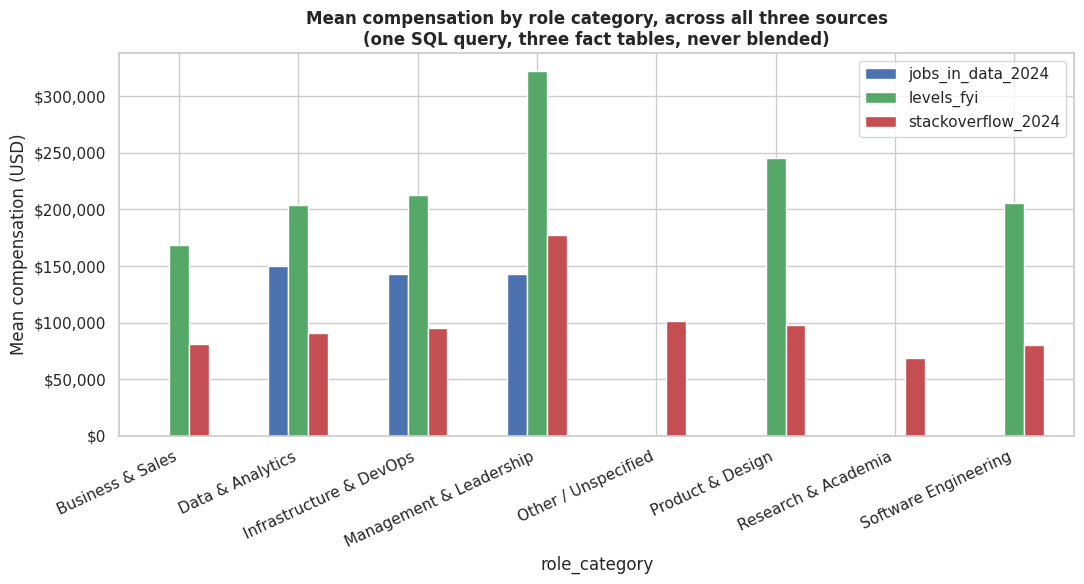

In [23]:
pivot = cross_source_result.pivot(index="role_category", columns="source", values="mean_comp_usd")
fig, ax = plt.subplots(figsize=(11, 6))
pivot.plot(kind="bar", ax=ax, color=[PALETTE[0], PALETTE[2], PALETTE[3]])
ax.set_title("Mean compensation by role category, across all three sources\n(one SQL query, three fact tables, never blended)", fontweight="bold")
ax.set_ylabel("Mean compensation (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
plt.xticks(rotation=25, ha="right")
ax.legend(title=None)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "16_cross_source_role_category_comparison.png", bbox_inches="tight")
plt.show()


### Observation

`Management & Leadership` and `Data & Analytics` both come out on top
across every source that has enough data to report them, with Levels.fyi
consistently the highest -- the Big-Tech skew Notebook 01 already
identified showing up again here, now visible *within* each role category
rather than only in the aggregate. Some role categories are entirely
absent from one or two sources (`jobs_in_data_2024` only covers
data-specialist categories, so `Business & Sales` and `Research &
Academia` never appear there) -- exactly the kind of gap a merged single
table would have hidden by silently coalescing to a partial average.


---
## Step 16 — Save the database and the role-family mapping documentation

**Why this step:** the populated SQLite file is a real, usable artifact --
and the role-family mapping deserves its own CSV so the judgment calls
made in Step 6 are easy to review or revise later without re-reading this
whole notebook.


In [24]:
conn.commit()

role_mapping_doc = pd.concat([
    pd.DataFrame({"source": "jobs_in_data_2024 (job_category)", "raw_value": list(JOB_CATEGORY_MAP.keys()),
                  "role_family_name": list(JOB_CATEGORY_MAP.values())}),
    pd.DataFrame({"source": "levels_fyi (title)", "raw_value": list(LEVELS_TITLE_MAP.keys()),
                  "role_family_name": list(LEVELS_TITLE_MAP.values())}),
    pd.DataFrame({"source": "stackoverflow_2024 (DevType)", "raw_value": list(SO_DEVTYPE_MAP.keys()),
                  "role_family_name": list(SO_DEVTYPE_MAP.values())}),
])
role_mapping_doc["role_category"] = role_mapping_doc["role_family_name"].map(ROLE_FAMILY_TO_CATEGORY)
role_mapping_doc.to_csv(REPORTS_DIR / "dim_role_family_mapping.csv", index=False)

country_resolution.reset_index().rename(columns={"index": "raw_country_string"}).to_csv(
    REPORTS_DIR / "dim_country_resolution.csv", index=False)

conn.close()
print(f"Database saved: {DB_PATH}  ({DB_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"Role mapping documentation saved: {len(role_mapping_doc)} rows")
print(f"Country resolution documentation saved: {len(country_resolution)} rows")


Database saved: notebooks/reports/job_market_warehouse.db  (64.5 MB)
Role mapping documentation saved: 59 rows
Country resolution documentation saved: 207 rows


---
## Summary

In this notebook I implemented the star schema `database/schema/*.sql` had
already designed, but that `database/load_data.py` explicitly stated wasn't
populated yet:

- Explained the design rationale already present in the DDL files:
  surrogate keys, year-grain dates, three fact tables never blended.
- Built the schema in SQLite (translated from the PostgreSQL target
  syntax) so it runs end-to-end with no external database server.
- Resolved `dim_country` across three inconsistent naming conventions
  using `pycountry` plus an explicit, documented override table --
  204/207 raw country strings resolved to a current ISO country, with the
  3 genuine non-matches (a dissolved country, a defunct federation, and
  one joke survey response) kept honest rather than force-mapped.
- Built `dim_education_level` as one shared ordered scale that both
  Levels.fyi's and Stack Overflow's differently-labeled education
  questions map onto completely.
- Built the `dim_role_family` mapping the project's own Technical Design
  Document flagged as unfinished -- 59 raw category/title/DevType values
  across three sources, mapped explicitly and verified against the live
  data for full coverage, saved as its own reviewable CSV.
- Loaded all three fact tables with fully resolved foreign keys, handling
  one real edge case along the way (5 Levels.fyi rows with no company
  name, resolved via an explicit `'Unknown'` dimension member rather than
  dropping real compensation data).
- Confirmed zero foreign-key violations database-wide via
  `PRAGMA foreign_key_check`, and zero orphaned rows in the Phase-6-built
  `bridge_respondent_skill` table against the freshly rebuilt
  `fact_so_respondent`.
- Ran the query this whole exercise was for: mean compensation by
  conformed role category, across all three sources, in one SQL statement
  -- something the flat Phase 3 CSVs could only do with hand-matched
  category names and much more code.

## Key Findings

- Country name inconsistency across sources is real and non-trivial (three
  different spellings for South Korea alone), but resolvable for 98.6% of
  values with a general-purpose ISO library plus a small, explicit
  override list.
- The `dim_role_family` mapping the project's docs called "unfinished" was
  fully buildable with 59 explicit rules -- not because it was secretly
  easy, but because writing the rules down and checking them against the
  actual data (rather than guessing) makes a seemingly big problem
  tractable.
- The star schema surfaces structural facts the flat CSVs hid: some role
  categories simply don't exist in some sources (e.g. no `Business &
  Sales` respondents in `jobs_in_data_2024`), which matters for anyone
  building a Power BI slicer that assumes every category is present in
  every table.

## Challenges Faced

- Deciding role-family boundaries for ambiguous titles (`"Recruiter"` vs.
  `"Human Resources"`, `"Developer, AI"` vs. a hypothetical dedicated "AI
  Engineer" family) required real judgment calls -- documented explicitly
  rather than hidden, since a reviewer should be able to disagree with a
  specific line, not just the general approach.
- SQLite's foreign key enforcement is opt-in per connection (`PRAGMA
  foreign_keys = ON`) and doesn't retroactively validate existing data --
  worth knowing before assuming "no errors during insert" is the same
  guarantee as "the database is internally consistent" (which is why Step
  14 runs an independent, explicit check rather than relying on insert-time
  enforcement alone).

## Decisions Taken

- Used SQLite instead of PostgreSQL for this notebook's implementation --
  the schema design remains PostgreSQL-targeted per the original DDL
  comments; SQLite is a portable stand-in that makes the notebook runnable
  without any external service.
- Added an explicit `'Unknown'` `dim_company` row rather than dropping the
  5 Levels.fyi rows with missing company names.
- Kept the 3 unresolvable `dim_country` entries as their original string
  labels with null ISO/continent fields, rather than force-mapping them to
  an approximate current country.
- Published the full `dim_role_family` mapping as a standalone,
  human-reviewable CSV rather than leaving the judgment calls implicit in
  code.

## Next Step

**Notebook 05** moves into Phase 5: full exploratory data analysis across
all three cleaned sources -- the 100+ documented insights referenced in
`data/docs/eda_insights.md`, now with the added ability to slice by the
conformed `role_family`/`role_category` dimensions built here.
